/var/folders/bv/zrggpwd94sgd6xprfdt6l9x00000gn/T/ipykernel_23965/3026627775.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


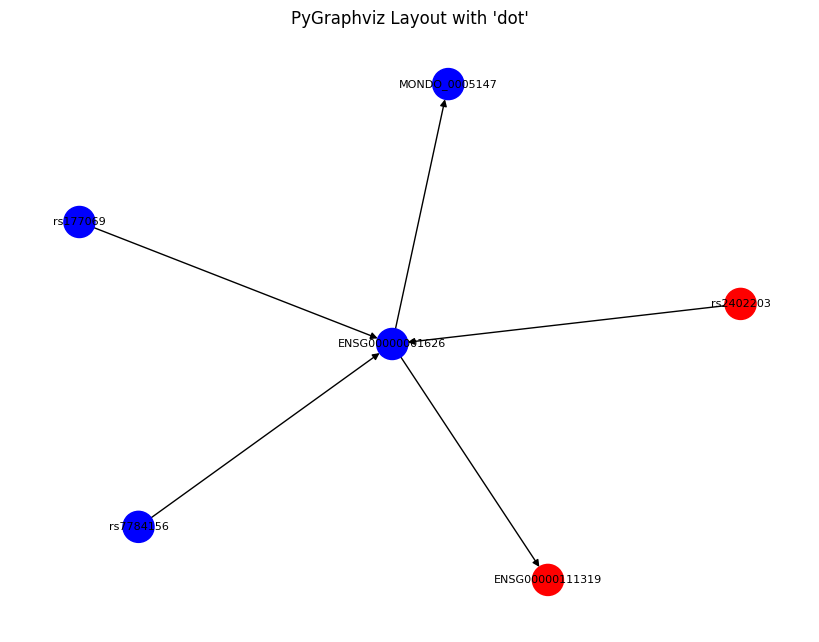

In [ ]:
import json
import pygraphviz as pgv
import matplotlib.pyplot as plt
import networkx as nx

# === Step 1: Load Neo4j query result ===
with open("Downloads/example_result_1.json") as f:
    data = json.load(f)

# === Step 2: Extract nodes and edges ===
seen_nodes = {}
edges = set()

for result in data["results"]:
    for node in result["nodes"]:
        node_id = node["~id"]
        seen_nodes[node_id] = True
    for edge in result["edges"]:
        start = edge["~start"]
        end = edge["~end"]
        edges.add((start, end))

# === Step 3: Build PyGraphviz graph ===
G = pgv.AGraph(strict=True, directed=True)
for node_id in seen_nodes:
    G.add_node(node_id)
for start, end in edges:
    G.add_edge(start, end)

# === Step 4: Layout and extract positions ===
G.layout(prog="neato")  # You can also try 'neato', 'fdp', etc.

core_nodes = {"ENSG00000111319", "rs2402203"}
x_y_dict = {}
for n in G.nodes():
    x, y = map(float, G.get_node(n).attr['pos'].split(','))
    level = "Core" if n in core_nodes else "Neighbor"
    x_y_dict[n] = {"x": x, "y": y, "Level": level}

with open("x_y.json", "w") as f:
    json.dump(x_y_dict, f, indent=2)

# === Step 5: Plotting with matplotlib using NetworkX wrapper ===
# Convert AGraph to NetworkX graph
nx_graph = nx.nx_agraph.from_agraph(G)

# Extract positions for plotting
positions = {node: (v["x"], v["y"]) for node, v in x_y_dict.items()}
colors = ["red" if v["Level"] == "Core" else "blue" for v in x_y_dict.values()]

plt.figure(figsize=(8, 6))
nx.draw(nx_graph, pos=positions, with_labels=True, node_color=colors, node_size=500, font_size=8)
plt.title("PyGraphviz Layout with 'dot'")
plt.axis("off")
plt.tight_layout()
plt.show()

/var/folders/bv/zrggpwd94sgd6xprfdt6l9x00000gn/T/ipykernel_23965/1632022137.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


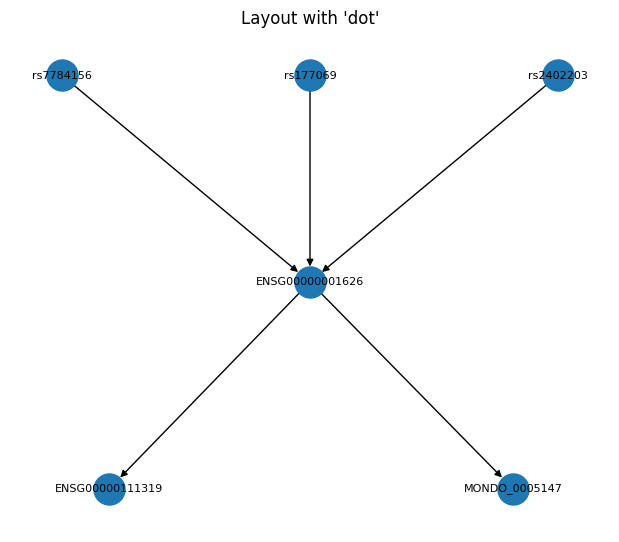

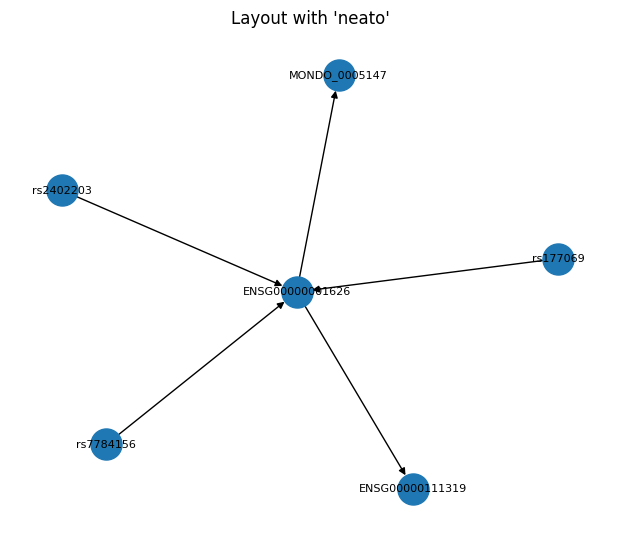

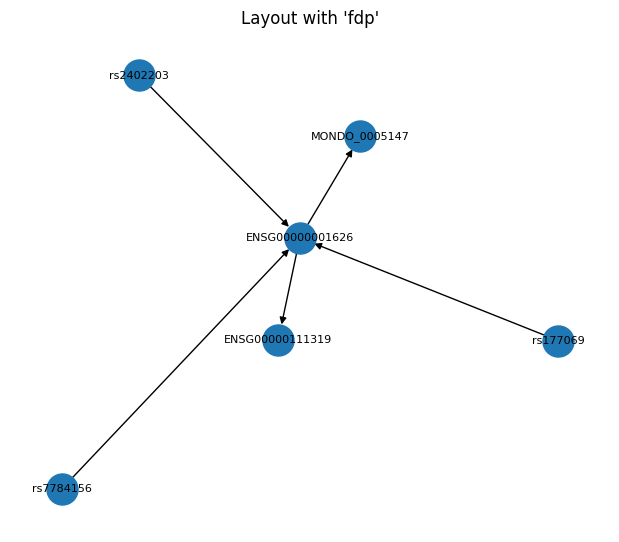

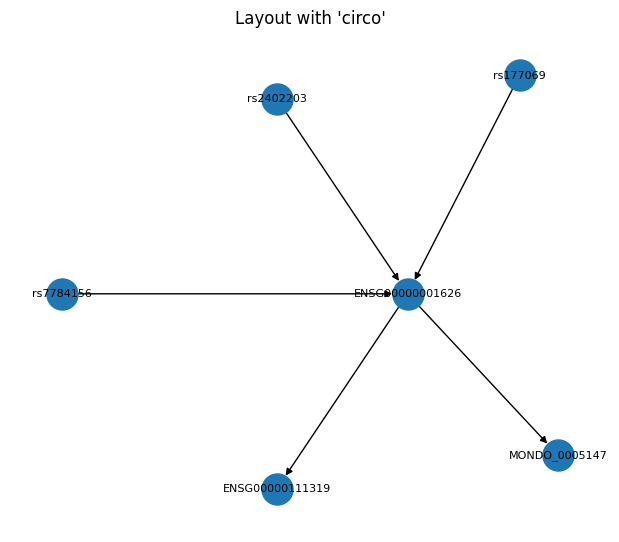

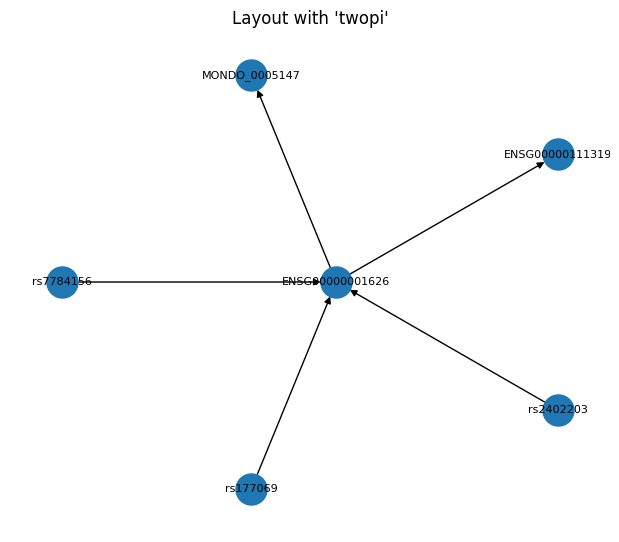

In [9]:
import pygraphviz as pgv
import matplotlib.pyplot as plt
import networkx as nx

layouts = ["dot", "neato", "fdp", "circo", "twopi"]

# Minimal edge list
edges = [
    ("rs7784156", "ENSG00000001626"),
    ("ENSG00000001626", "ENSG00000111319"),
    ("rs177069", "ENSG00000001626"),
    ("rs2402203", "ENSG00000001626"),
    ("ENSG00000001626", "MONDO_0005147")
]

for layout in layouts:
    G = pgv.AGraph(strict=True, directed=True)
    for s, t in edges:
        G.add_edge(s, t)
    G.layout(prog=layout)

    nx_graph = nx.nx_agraph.from_agraph(G)
    pos = {n: tuple(map(float, G.get_node(n).attr['pos'].split(','))) for n in G.nodes()}

    plt.figure(figsize=(6, 5))
    nx.draw(nx_graph, pos=pos, with_labels=True, node_size=500, font_size=8)
    plt.title(f"Layout with '{layout}'")
    plt.axis("off")
    plt.tight_layout()
    plt.show()